# Task 3

In [34]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import sem

class BinaryAlloySimulation:
    def __init__(self, L, DA, DB, coverage_limit=0.2):
        self.L = L
        self.grid = np.zeros((L, L), dtype=int)  # 0: empty, 1: A, 2: B, 3: island
        self.DA = DA
        self.DB = DB
        self.coverage_limit = coverage_limit
        self.F = 1.0  # 1 layer/s
        
        # Track island composition
        self.island_composition = {
            'A': [],  # Track number of A particles in each island
            'B': []   # Track number of B particles in each island
        }
        
        # Time evolution tracking
        self.time_evolution = {
            'A_monomers': [],
            'B_monomers': [],
            'islands': [],
            'coverage': [],
            'mixing_index': []  # Track how well mixed the islands are
        }
    
    def get_coverage(self):
        return np.sum(self.grid != 0) / (self.L * self.L)
    
    def deposit_particle(self, particle_type):
        if self.get_coverage() >= self.coverage_limit:
            return False
            
        empty_sites = np.where(self.grid == 0)
        if len(empty_sites[0]) > 0:
            idx = np.random.randint(len(empty_sites[0]))
            x, y = empty_sites[0][idx], empty_sites[1][idx]
            self.grid[x, y] = particle_type
            return True
        return False
    
    def diffuse_particles(self):
        # Diffuse A particles
        A_positions = np.where(self.grid == 1)
        for idx in range(len(A_positions[0])):
            x, y = A_positions[0][idx], A_positions[1][idx]
            if self.grid[x, y] != 1:  # Skip if no longer a monomer
                continue
            self.diffuse_single_particle(x, y, self.DA)
        
        # Diffuse B particles
        B_positions = np.where(self.grid == 2)
        for idx in range(len(B_positions[0])):
            x, y = B_positions[0][idx], B_positions[1][idx]
            if self.grid[x, y] != 2:  # Skip if no longer a monomer
                continue
            self.diffuse_single_particle(x, y, self.DB)
    
    def diffuse_single_particle(self, x, y, D):
        for _ in range(int(D)):
            if self.grid[x, y] >= 3:  # Skip if part of island
                break
                
            direction = np.random.choice(['x', 'y'])
            if direction == 'x':
                new_x = (x + np.random.choice([-1, 1])) % self.L
                new_y = y
            else:
                new_x = x
                new_y = (y + np.random.choice([-1, 1])) % self.L
            
            if self.grid[new_x, new_y] == 0:
                particle_type = self.grid[x, y]
                self.grid[x, y] = 0
                self.grid[new_x, new_y] = particle_type
                x, y = new_x, new_y
                
                if self.check_aggregation(x, y):
                    break
    
    def check_aggregation(self, x, y):
        particle_type = self.grid[x, y]
        neighbors = [
            ((x+1)%self.L, y),
            ((x-1)%self.L, y),
            (x, (y+1)%self.L),
            (x, (y-1)%self.L)
        ]
        
        for nx, ny in neighbors:
            if self.grid[nx, ny] in [1, 2, 3]:  # If neighbor is a particle or island
                # Create new island ID (>= 3)
                new_island_id = 3
                self.grid[x, y] = new_island_id
                self.grid[nx, ny] = new_island_id
                return True
        return False
    
    def calculate_mixing_index(self):
        """Calculate how well mixed the islands are"""
        islands = np.where(self.grid >= 3)
        if len(islands[0]) == 0:
            return 0
            
        A_count = np.sum(self.grid == 1)
        B_count = np.sum(self.grid == 2)
        ideal_ratio = A_count / (A_count + B_count) if (A_count + B_count) > 0 else 0.5
        
        island_ratios = []
        for x, y in zip(islands[0], islands[1]):
            neighbors = [
                ((x+1)%self.L, y),
                ((x-1)%self.L, y),
                (x, (y+1)%self.L),
                (x, (y-1)%self.L)
            ]
            local_A = sum(1 for nx, ny in neighbors if self.grid[nx, ny] == 1)
            local_B = sum(1 for nx, ny in neighbors if self.grid[nx, ny] == 2)
            if local_A + local_B > 0:
                island_ratios.append(abs(local_A/(local_A + local_B) - ideal_ratio))
        
        return 1 - np.mean(island_ratios) if island_ratios else 0
    
    def run_simulation(self, steps):
        for step in range(steps):
            # Alternate between A and B deposition
            if step % 2 == 0:
                if not self.deposit_particle(1):  # Deposit A
                    break
            else:
                if not self.deposit_particle(2):  # Deposit B
                    break
            
            self.diffuse_particles()
            
            # Track evolution
            self.time_evolution['A_monomers'].append(np.sum(self.grid == 1))
            self.time_evolution['B_monomers'].append(np.sum(self.grid == 2))
            self.time_evolution['islands'].append(np.sum(self.grid >= 3))
            self.time_evolution['coverage'].append(self.get_coverage())
            self.time_evolution['mixing_index'].append(self.calculate_mixing_index())

# Run simulations for different DB/DA ratios
L = 100
steps = 1000
DA = 1e4  # Fixed DA
#DB_ratios = [0.001, 0.01, 0.1, 1.0, 10, 100]  # DB/DA ratios to test
DB_ratios = np.logspace(-2, 2, num=10)
simulations = []

for ratio in DB_ratios:
    DB = DA * ratio
    sim = BinaryAlloySimulation(L=L, DA=DA, DB=DB)
    sim.run_simulation(steps)
    simulations.append(sim)

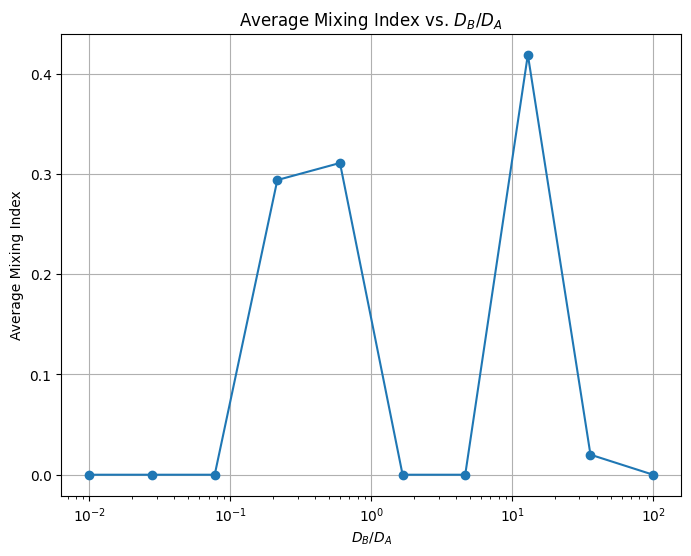

In [35]:

# Final Mixing Index vs. D_B/D_A
mixing_indices = [np.average(sim.time_evolution['mixing_index']) for sim in simulations]  # Final mixing index

plt.figure(figsize=(8, 6))
plt.plot(DB_ratios, mixing_indices, marker='o', linestyle='-')
plt.xscale('log')
plt.xlabel(r'$D_B/D_A$')
plt.ylabel('Average Mixing Index')
plt.title(r'Average Mixing Index vs. $D_B/D_A$')
plt.grid(True)
plt.show()

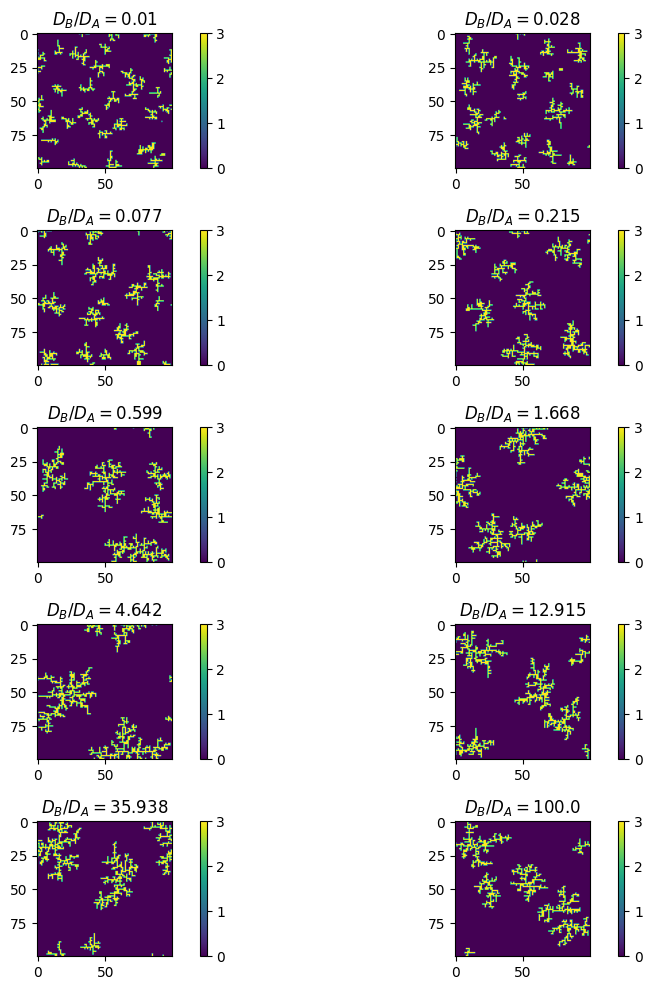

In [37]:
# Plot final configurations
fig, axs = plt.subplots(5, 2, figsize=(10, 10))
for idx, (sim, ratio) in enumerate(zip(simulations, DB_ratios)):
    i, j = idx // 2, idx % 2
    im = axs[i,j].imshow(sim.grid, cmap='viridis')
    axs[i,j].set_title(rf'$D_B/D_A = {np.round(ratio,3)}$')
    plt.colorbar(im, ax=axs[i,j])

plt.tight_layout()
plt.show()